
Processing road...


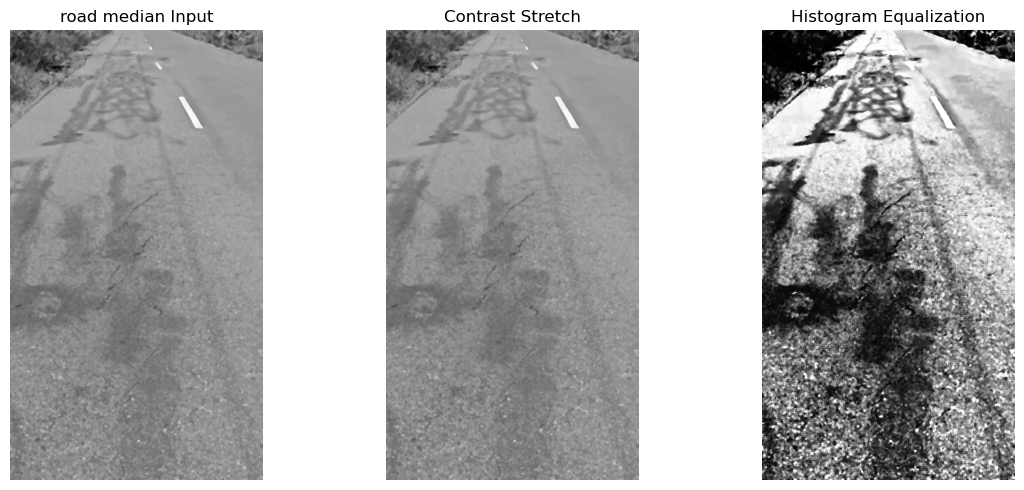

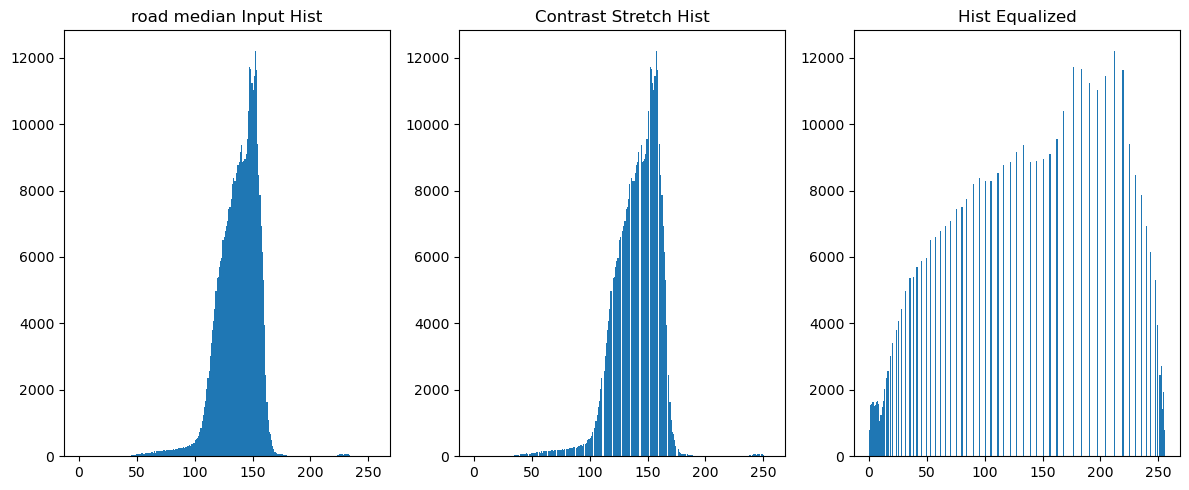

road: Processed median frame 1
road: Processed gaussian frame 1
road: Processed median frame 2
road: Processed gaussian frame 2
road: Processed median frame 3
road: Processed gaussian frame 3
road: Processed median frame 4
road: Processed gaussian frame 4
road: Processed median frame 5
road: Processed gaussian frame 5
road: Processed median frame 6
road: Processed gaussian frame 6
road: Processed median frame 7
road: Processed gaussian frame 7
road: Processed median frame 8
road: Processed gaussian frame 8
road: Processed median frame 9
road: Processed gaussian frame 9
road: Processed median frame 10
road: Processed gaussian frame 10
road: Processed median frame 11
road: Processed gaussian frame 11
road: Processed median frame 12
road: Processed gaussian frame 12
road: Processed median frame 13
road: Processed gaussian frame 13
road: Processed median frame 14
road: Processed gaussian frame 14
road: Processed median frame 15
road: Processed gaussian frame 15
road: Processed median frame

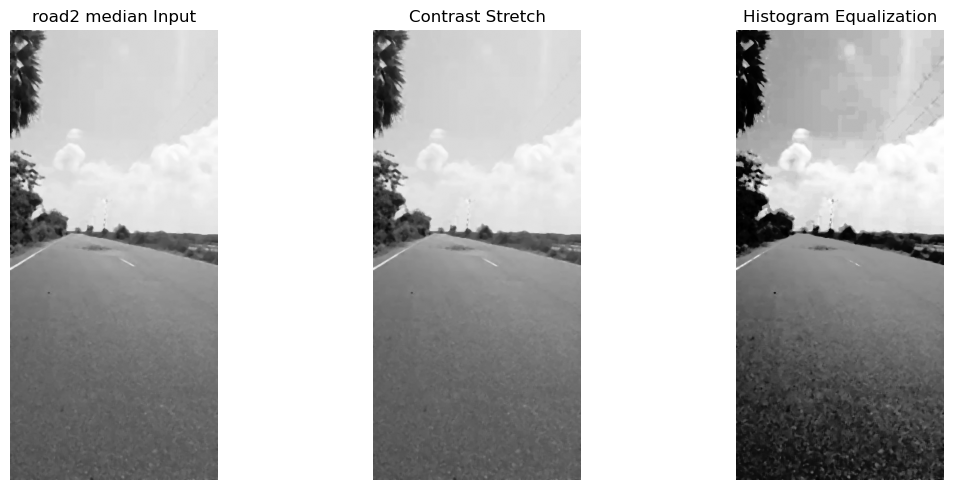

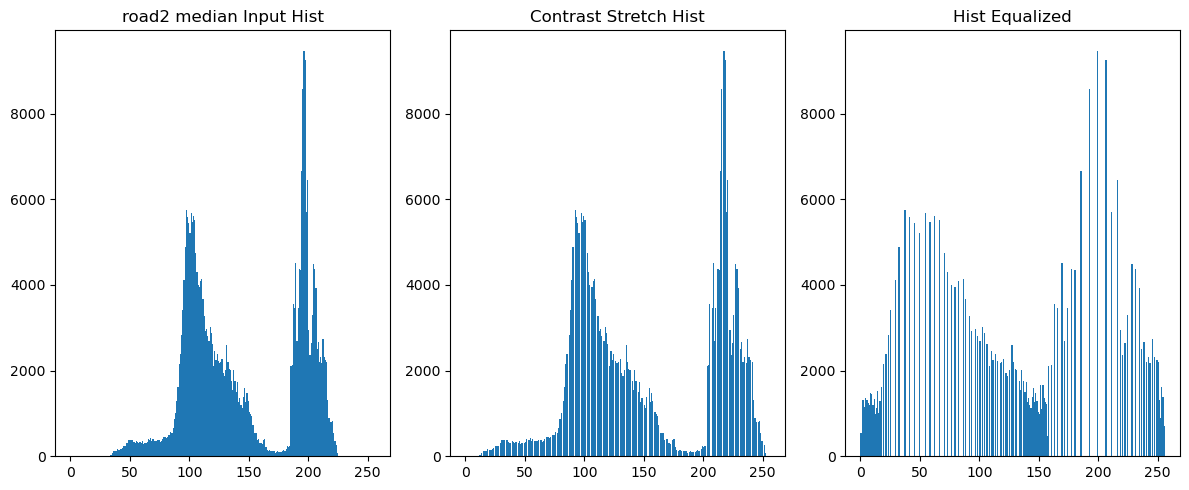

road2: Processed median frame 1
road2: Processed gaussian frame 1
road2: Processed median frame 2
road2: Processed gaussian frame 2
road2: Processed median frame 3
road2: Processed gaussian frame 3
road2: Processed median frame 4
road2: Processed gaussian frame 4
road2: Processed median frame 5
road2: Processed gaussian frame 5
road2: Processed median frame 6
road2: Processed gaussian frame 6
road2: Processed median frame 7
road2: Processed gaussian frame 7
road2: Processed median frame 8
road2: Processed gaussian frame 8
road2: Processed median frame 9
road2: Processed gaussian frame 9
road2: Processed median frame 10
road2: Processed gaussian frame 10
road2: Processed median frame 11
road2: Processed gaussian frame 11
road2: Processed median frame 12
road2: Processed gaussian frame 12
road2: Processed median frame 13
road2: Processed gaussian frame 13
road2: Processed median frame 14
road2: Processed gaussian frame 14
road2: Processed median frame 15
road2: Processed gaussian frame 1

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

num_frames = 30
display_frame = 1   # to show one example frame in notebook
videos = ["road", "road2"]   # video names

def contrast_stretching(img):
    if img.max() == img.min():
        return img
    return ((img - img.min()) / (img.max() - img.min()) * 255).astype('uint8')

for video in videos:

    print(f"\nProcessing {video}...")

    # -------- INPUT FOLDERS --------
    input_folders = {
        "median": f"{video}_member1_median",
        "gaussian": f"{video}_member1_gaussian"
    }

    # -------- OUTPUT FOLDERS --------
    output_folders = {
        "median_contrast": f"{video}_member2_median_contrast",
        "median_hist_eq": f"{video}_member2_median_hist_eq",
        "gaussian_contrast": f"{video}_member2_gaussian_contrast",
        "gaussian_hist_eq": f"{video}_member2_gaussian_hist_eq",
        "comparisons": f"{video}_member2_comparisons",
        "histograms": f"{video}_member2_histograms"
    }

    # Create folders
    for folder in output_folders.values():
        os.makedirs(folder, exist_ok=True)

    shown_image = False
    shown_hist = False

    for idx in range(1, num_frames + 1):

        for filter_type in input_folders:

            input_path = f"{input_folders[filter_type]}/frame_{idx}.jpg"
            img = cv2.imread(input_path, 0)

            if img is None:
                print(f"{video} {filter_type} frame {idx} not found")
                continue

            # -------- ENHANCEMENT --------
            contrast_img = contrast_stretching(img)
            hist_eq_img = cv2.equalizeHist(img)

            # -------- SAVE ENHANCED IMAGES --------
            cv2.imwrite(
                f"{output_folders[f'{filter_type}_contrast']}/frame_{idx}.jpg",
                contrast_img
            )

            cv2.imwrite(
                f"{output_folders[f'{filter_type}_hist_eq']}/frame_{idx}.jpg",
                hist_eq_img
            )

            # -------- IMAGE COMPARISON --------
            plt.figure(figsize=(12, 5))

            plt.subplot(1, 3, 1)
            plt.imshow(img, cmap='gray')
            plt.title(f"{video} {filter_type} Input")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(contrast_img, cmap='gray')
            plt.title("Contrast Stretch")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(hist_eq_img, cmap='gray')
            plt.title("Histogram Equalization")
            plt.axis('off')

            plt.tight_layout()
            plt.savefig(
                f"{output_folders['comparisons']}/{filter_type}_comparison_{idx}.jpg"
            )

            # Show only one selected frame in notebook for each video
            if idx == display_frame and not shown_image:
                plt.show()
                shown_image = True
            else:
                plt.close()

            # -------- HISTOGRAM COMPARISON --------
            plt.figure(figsize=(12, 5))

            plt.subplot(1, 3, 1)
            plt.hist(img.ravel(), bins=256, range=[0, 256])
            plt.title(f"{video} {filter_type} Input Hist")

            plt.subplot(1, 3, 2)
            plt.hist(contrast_img.ravel(), bins=256, range=[0, 256])
            plt.title("Contrast Stretch Hist")

            plt.subplot(1, 3, 3)
            plt.hist(hist_eq_img.ravel(), bins=256, range=[0, 256])
            plt.title("Hist Equalized")

            plt.tight_layout()
            plt.savefig(
                f"{output_folders['histograms']}/{filter_type}_hist_{idx}.png"
            )

            # Show only one histogram in notebook for each video
            if idx == display_frame and not shown_hist:
                plt.show()
                shown_hist = True
            else:
                plt.close()

            print(f"{video}: Processed {filter_type} frame {idx}")

print("\nMember 2 processing complete.")